#App User Behavior Segmentation Using Unsupervised Machine Learning


##IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##LOAD THE DATASET

In [ ]:
df = pd.read_csv("/content/app_user_behavior_dataset.csv")
df.head()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign


##DATASET OVERVIEW

In [ ]:
print("Shape:", df.shape)

Shape: (50000, 25)


In [ ]:
print("Data Types:")
print(df.dtypes)

Data Types:
user_id                            int64
age                                int64
gender                            object
country                           object
device_type                       object
app_version                      float64
sessions_per_week                  int64
avg_session_duration_min         float64
daily_active_minutes             float64
feature_clicks_per_session         int64
notifications_opened_per_week      int64
in_app_search_count                int64
pages_viewed_per_session           int64
crash_events_last_30_days          int64
support_tickets_raised             int64
days_since_last_login              int64
subscription_type                 object
ads_clicked_last_30_days           int64
content_downloads                  int64
social_shares                      int64
rating_given                     float64
churn_risk_score                 float64
engagement_score                 float64
account_age_days                   int64
mark

In [ ]:
print("Statistics:")
print(df.describe())

Statistics:
             user_id           age   app_version  sessions_per_week  \
count   50000.000000  50000.000000  50000.000000       50000.000000   
mean   124999.500000     38.513040      1.476126           7.999680   
std     14433.901067     12.094948      0.470158           2.829438   
min    100000.000000     18.000000      1.000000           0.000000   
25%    112499.750000     28.000000      1.100000           6.000000   
50%    124999.500000     39.000000      1.200000           8.000000   
75%    137499.250000     49.000000      2.000000          10.000000   
max    149999.000000     59.000000      2.100000          26.000000   

       avg_session_duration_min  daily_active_minutes  \
count              50000.000000          50000.000000   
mean                  13.149842             45.164537   
std                    8.946944             19.505118   
min                    0.060000              5.000000   
25%                    6.570000             31.650000   
50%   

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
user_id                             0
age                                 0
gender                              0
country                             0
device_type                         0
app_version                         0
sessions_per_week                   0
avg_session_duration_min            0
daily_active_minutes                0
feature_clicks_per_session          0
notifications_opened_per_week       0
in_app_search_count                 0
pages_viewed_per_session            0
crash_events_last_30_days           0
support_tickets_raised              0
days_since_last_login               0
subscription_type                   0
ads_clicked_last_30_days            0
content_downloads                   0
social_shares                       0
rating_given                     5022
churn_risk_score                    0
engagement_score                    0
account_age_days                    0
marketing_source                    0
dtype: int64


In [ ]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


##DATASET CLEANING

In [ ]:
df.drop(columns=["rating_given"], inplace=True)

In [ ]:
print("After Cleaning:")
print("\nShape:", df.shape)
print("\nMissing Values:", df.isnull().sum().sum())
print("\nDuplicates:", df.duplicated().sum())

After Cleaning:

Shape: (50000, 24)

Missing Values: 0

Duplicates: 0


##EDA

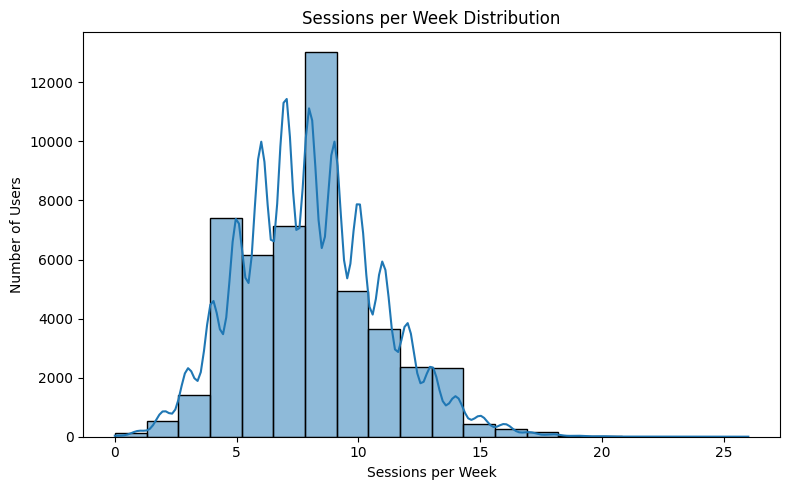

In [ ]:
# Chart 1: Sessions per week
plt.figure(figsize=(8, 5))
sns.histplot(
    df["sessions_per_week"],
    bins=20,
    kde=True
)
plt.title("Sessions per Week Distribution")
plt.xlabel("Sessions per Week")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()


###Insight:  
* User engagement is primarily concentrated in the 5–12 sessions/week range, suggesting moderate and consistent weekly usage.


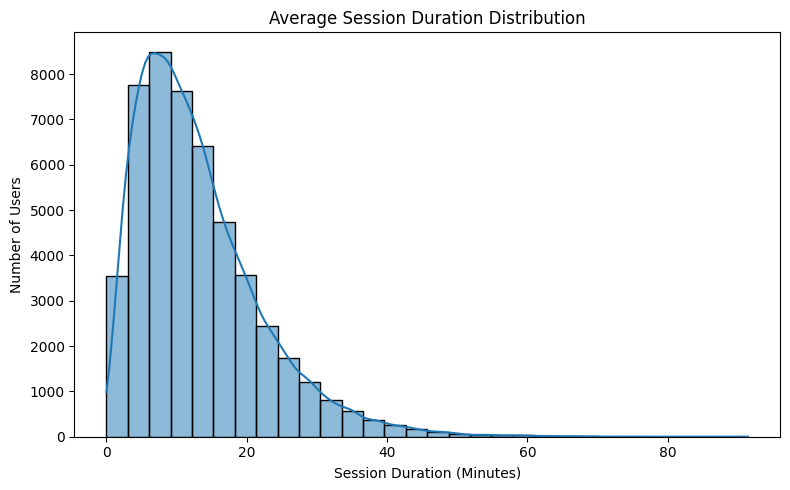

In [ ]:
# Chart 2: Session duration
plt.figure(figsize=(8, 5))
sns.histplot(
    df["avg_session_duration_min"],
    bins=30,
    kde=True
)
plt.title("Average Session Duration Distribution")
plt.xlabel("Session Duration (Minutes)")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

###Insight:
* User engagement is predominantly short-to-moderate in duration, suggesting
users tend to interact frequently but for relatively brief periods.

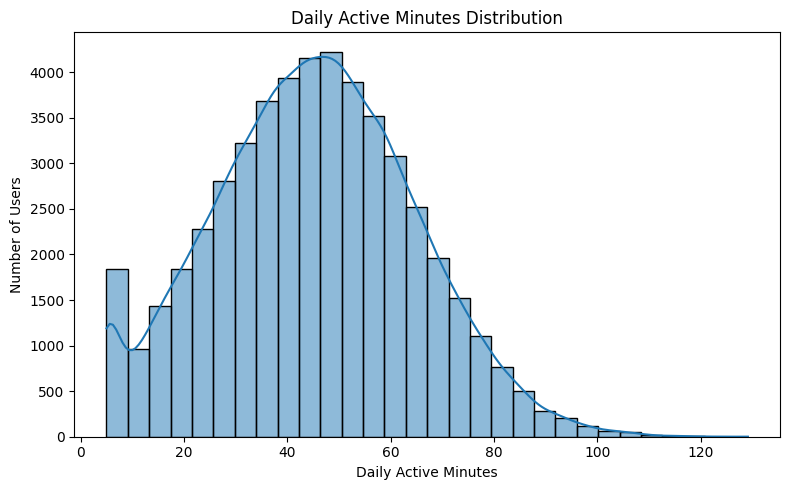

In [ ]:
# Chart 3: Daily active minutes
plt.figure(figsize=(8, 5))
sns.histplot(
    df["daily_active_minutes"],
    bins=30,
    kde=True
)
plt.title("Daily Active Minutes Distribution")
plt.xlabel("Daily Active Minutes")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()


###Insight: Most users are moderately engaged on a daily basis, typically

* Most users are moderately engaged on a daily basis, typically spending around 40–60 active minutes per day.

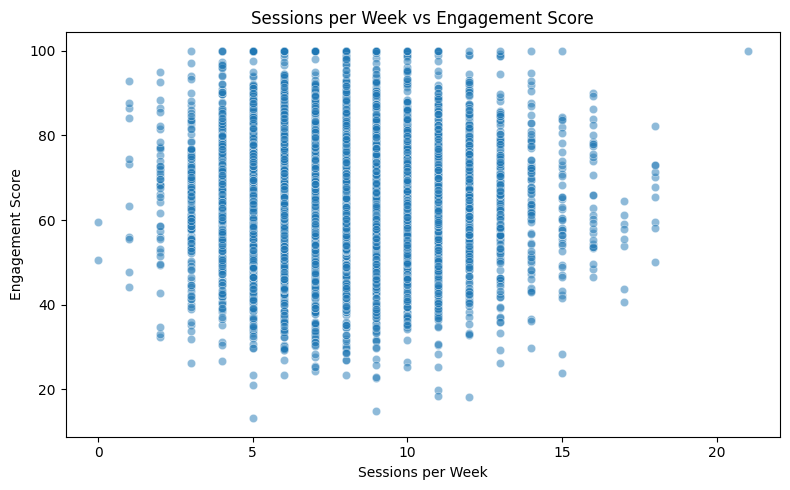

In [ ]:
# Chart 4: Engagement vs sessions
sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=sample_df,
    x="sessions_per_week",
    y="engagement_score",
    alpha=0.5
)
plt.title("Sessions per Week vs Engagement Score")
plt.xlabel("Sessions per Week")
plt.ylabel("Engagement Score")
plt.tight_layout()
plt.show()

Insight:

* Session frequency alone is not a strong predictor of engagement; other factors likely contribute significantly to engagement scores.


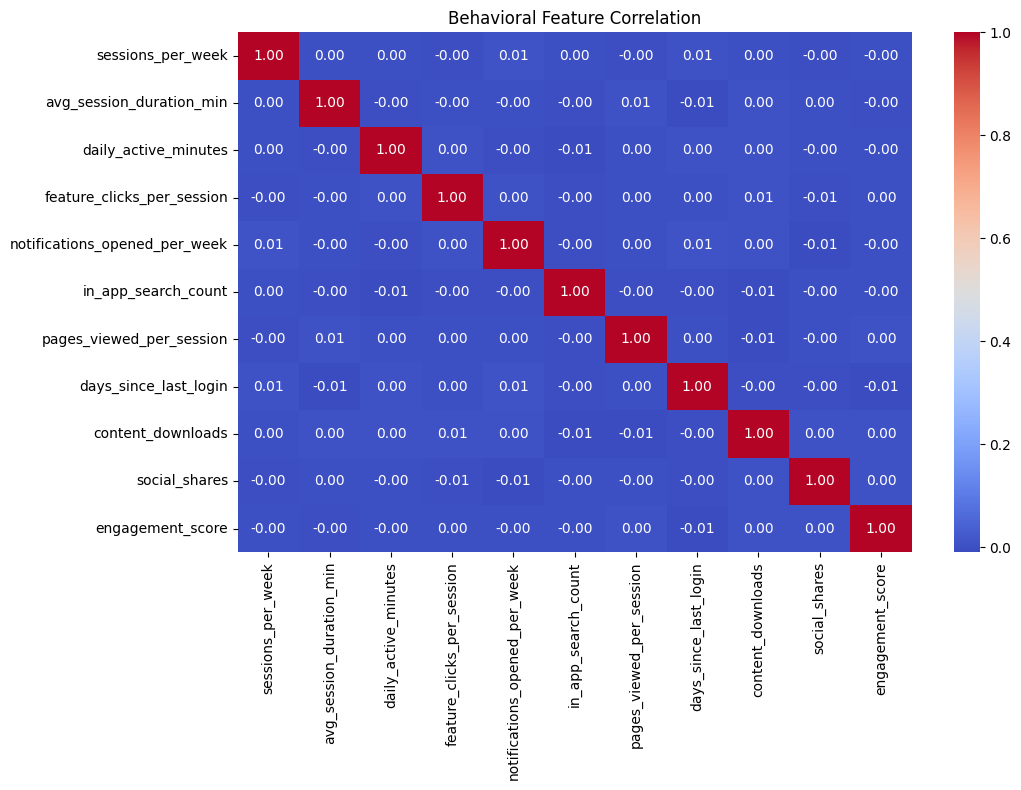

In [ ]:
# Chart 5: Behavioral correlation
corr_cols = [
    "sessions_per_week",
    "avg_session_duration_min",
    "daily_active_minutes",
    "feature_clicks_per_session",
    "notifications_opened_per_week",
    "in_app_search_count",
    "pages_viewed_per_session",
    "days_since_last_login",
    "content_downloads",
    "social_shares",
    "engagement_score"
]

plt.figure(figsize=(11, 8))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Behavioral Feature Correlation")
plt.tight_layout()
plt.show()

##Insights:

*  **Correlation:** All behavioral features show very weak or near-zero correlations with each other.
*  **Engagement score:** Engagement score has almost no linear correlation with the measured behavioral features.

*  **Key implication:** The variables appear largely independent, suggesting no single behavioral metric strongly explains engagement.




##FEATURE ENGINEERING

In [ ]:
df["weekly_engagement_minutes"] = (
    df["sessions_per_week"] *
    df["avg_session_duration_min"]
)

df["interaction_score"] = (
    df["feature_clicks_per_session"]
    + df["notifications_opened_per_week"]
    + df["in_app_search_count"]
)

df["content_activity"] = (
    df["content_downloads"]
    + df["social_shares"]
)

##SELECT BEHAVIORAL FEATURES

In [ ]:
features = [
    "weekly_engagement_minutes",
    "interaction_score",
    "content_activity"
]

X = df[features].copy()

print("\nSelected Features:")
print(features)

print("\nFeature Summary:")
print(X.describe())


Selected Features:
['weekly_engagement_minutes', 'interaction_score', 'content_activity']

Feature Summary:
       weekly_engagement_minutes  interaction_score  content_activity
count               50000.000000       50000.000000      50000.000000
mean                  105.201861          21.009600          5.003700
std                    84.604167           4.595908          2.239524
min                     0.000000           6.000000          0.000000
25%                    45.717500          18.000000          3.000000
50%                    82.880000          21.000000          5.000000
75%                   139.752500          24.000000          6.000000
max                  1098.540000          41.000000         17.000000


##LOG TRANSFORMATION

In [ ]:
for col in features:
    X[col] = np.log1p(X[col])

##STANDARD SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

##K-MEANS: TEST DIFFERENT K VALUES

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
results = []

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=30
    )

    labels = model.fit_predict(X_scaled)

    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    results.append([
        k,
        model.inertia_,
        silhouette
    ])


results = pd.DataFrame(
    results,
    columns=[
        "K",
        "Inertia",
        "Silhouette"
    ]
)

print("\n" + "=" * 60)
print("K-MEANS RESULTS")
print("=" * 60)

print(results)



K-MEANS RESULTS
   K        Inertia  Silhouette
0  2  118152.442947    0.218311
1  3   93941.765111    0.235622
2  4   73955.706083    0.251815
3  5   66573.846336    0.221543
4  6   60553.166443    0.218027
5  7   55868.688158    0.212910
6  8   51794.480518    0.213051


##ELBOW CHART

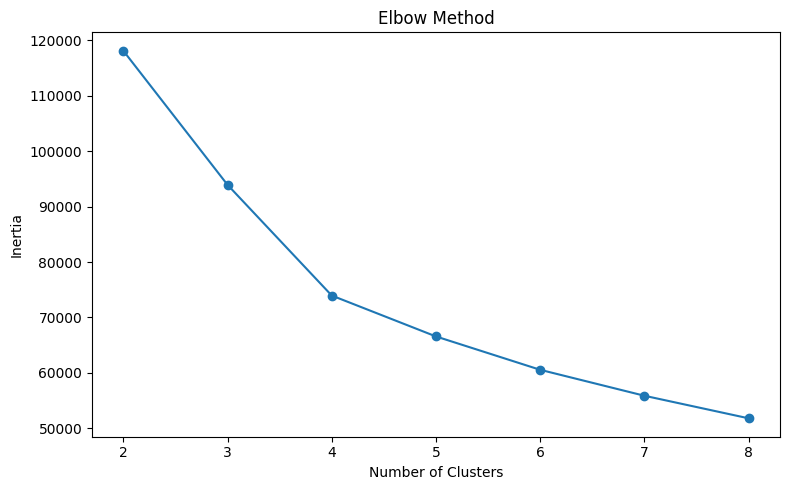

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    results["K"],
    results["Inertia"],
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(2, 9))
plt.tight_layout()
plt.show()


##SILHOUETTE CHART

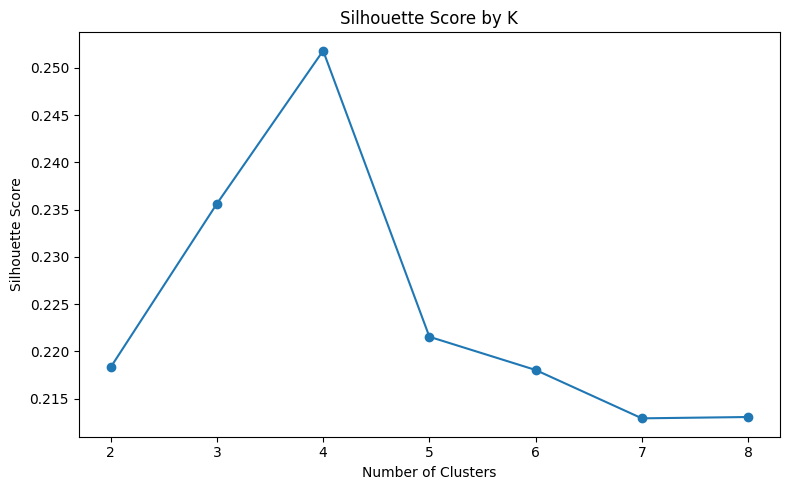

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    results["K"],
    results["Silhouette"],
    marker="o"
)

plt.title("Silhouette Score by K")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 9))
plt.tight_layout()
plt.show()

##FINAL K-MEANS MODEL

In [ ]:
best_k = 4

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=30
)

df["cluster"] = kmeans.fit_predict(X_scaled)

##FINAL SILHOUETTE SCORE

In [ ]:
final_silhouette = silhouette_score(
    X_scaled,
    df["cluster"]
)

print("\n" + "=" * 60)
print("FINAL K-MEANS RESULT")
print("=" * 60)

print(
    "K =", best_k
)

print(
    "Silhouette Score =",
    round(final_silhouette, 4)
)


FINAL K-MEANS RESULT
K = 4
Silhouette Score = 0.2518


##CLUSTER COUNTS

In [ ]:
cluster_counts = (
    df["cluster"]
    .value_counts()
    .sort_index()
)

print("\nCluster Counts:")
print(cluster_counts)


Cluster Counts:
cluster
0    17110
1    12071
2    11200
3     9619
Name: count, dtype: int64


##CLUSTER SIZE CHART

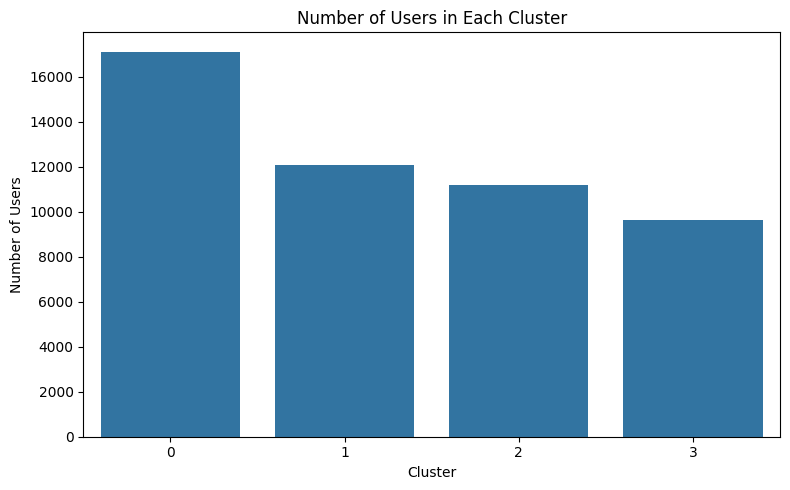

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Users in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()


##CLUSTER PROFILE

In [ ]:
profile_features = [
    "weekly_engagement_minutes",
    "interaction_score",
    "content_activity",
    "sessions_per_week",
    "avg_session_duration_min",
    "daily_active_minutes",
    "days_since_last_login"
]

profile = (
    df.groupby("cluster")[profile_features]
    .mean()
    .round(2)
)

print("\n" + "=" * 60)
print("CLUSTER PROFILE")
print("=" * 60)

print(profile)


CLUSTER PROFILE
         weekly_engagement_minutes  interaction_score  content_activity  \
cluster                                                                   
0                           142.31              23.77              6.05   
1                           115.22              15.74              5.45   
2                            29.20              21.75              5.35   
3                           115.11              21.85              2.18   

         sessions_per_week  avg_session_duration_min  daily_active_minutes  \
cluster                                                                      
0                     8.69                     16.85                 45.25   
1                     8.22                     14.39                 45.10   
2                     6.53                      5.20                 45.23   
3                     8.22                     14.26                 45.02   

         days_since_last_login  
cluster                       


PCA Explained Variance: 0.6685


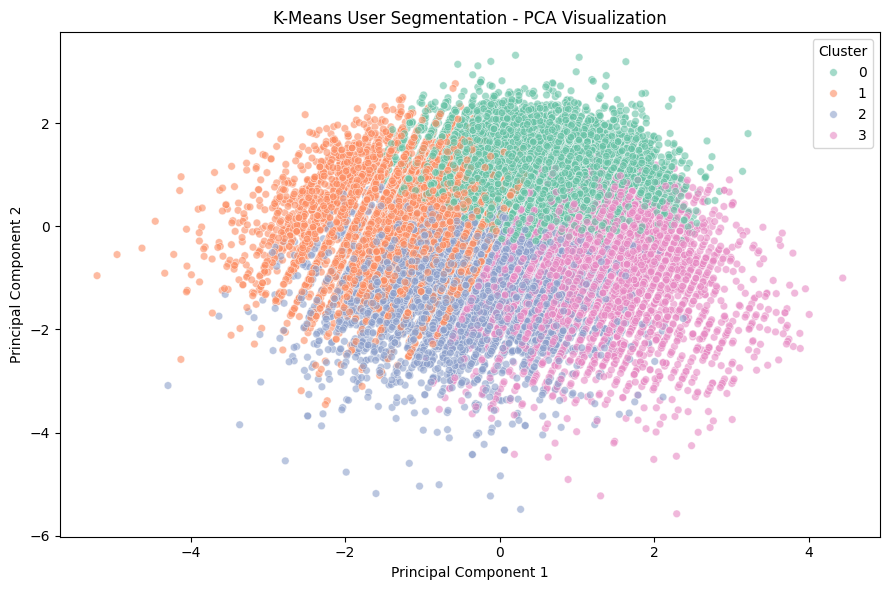

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA Explained Variance:",
      round(
          pca.explained_variance_ratio_.sum(),
          4
      ))


plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df["cluster"],
    palette="Set2",
    alpha=0.6,
    s=30
)

plt.title("K-Means User Segmentation - PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

###Insights:

* Four distinct segments: K-Means identifies 4 user clusters, with separation mainly along the PCA dimensions.noticeable

*  Cluster patterns: Clusters 0 and 1 are concentrated toward higher and middle PCA values, while 2 and 3 are more concentrated in the lower region.

* Overlap: There is substantial overlap between clusters, indicating that user behaviors are not sharply separated.

##AGGLOMERATIVE CLUSTERING COMPARISON

In [ ]:
sample_size = min(10000, len(X_scaled))

rng = np.random.RandomState(42)

sample_idx = rng.choice(
    len(X_scaled),
    sample_size,
    replace=False
)

X_sample = X_scaled[sample_idx]


# K-Means on sample
kmeans_sample = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=30
)

kmeans_sample_labels = (
    kmeans_sample.fit_predict(X_sample)
)

kmeans_sample_score = silhouette_score(
    X_sample,
    kmeans_sample_labels
)


# Agglomerative
agg = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

agg_labels = agg.fit_predict(X_sample)

agg_score = silhouette_score(
    X_sample,
    agg_labels
)


print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(
    "K-Means Silhouette:",
    round(kmeans_sample_score, 4)
)

print(
    "Agglomerative Silhouette:",
    round(agg_score, 4)
)



MODEL COMPARISON
K-Means Silhouette: 0.2517
Agglomerative Silhouette: 0.1794


##FINAL BUSINESS SEGMENT NAMES

In [ ]:
cluster_names = {
    0: "High Engagement",
    1: "Low Engagement / At-Risk",
    2: "Moderate Engagement",
    3: "Occasional / Content-Light"
}

df["segment"] = df["cluster"].map(
    cluster_names
)


##FINAL BUSINESS SEGMENT NAMES

In [ ]:
cluster_names = {
    0: "High Engagement",
    1: "Low Engagement / At-Risk",
    2: "Moderate Engagement",
    3: "Occasional / Content-Light"
}

df["segment"] = df["cluster"].map(
    cluster_names
)

##CUSTOMER-LEVEL IDENTIFICATION

In [ ]:
customer_segments = df[
    [
        "user_id",
        "cluster",
        "segment"
    ]
].copy()

print("\n" + "=" * 60)
print("CUSTOMER-LEVEL SEGMENTS")
print("=" * 60)

print(
    customer_segments.head(20)
)



CUSTOMER-LEVEL SEGMENTS
    user_id  cluster                     segment
0    100000        2         Moderate Engagement
1    100001        1    Low Engagement / At-Risk
2    100002        1    Low Engagement / At-Risk
3    100003        2         Moderate Engagement
4    100004        0             High Engagement
5    100005        0             High Engagement
6    100006        3  Occasional / Content-Light
7    100007        2         Moderate Engagement
8    100008        0             High Engagement
9    100009        0             High Engagement
10   100010        1    Low Engagement / At-Risk
11   100011        1    Low Engagement / At-Risk
12   100012        3  Occasional / Content-Light
13   100013        1    Low Engagement / At-Risk
14   100014        0             High Engagement
15   100015        0             High Engagement
16   100016        0             High Engagement
17   100017        3  Occasional / Content-Light
18   100018        1    Low Engagement / At-

##SEGMENT COUNTS

In [ ]:
segment_counts = (
    df["segment"]
    .value_counts()
)

print("\nSegment Counts:")
print(segment_counts)


Segment Counts:
segment
High Engagement               17110
Low Engagement / At-Risk      12071
Moderate Engagement           11200
Occasional / Content-Light     9619
Name: count, dtype: int64


##BUSINESS PROFILE

In [ ]:
business_profile = (
    df.groupby("segment")[
        [
            "sessions_per_week",
            "avg_session_duration_min",
            "daily_active_minutes",
            "days_since_last_login"
        ]
    ]
    .mean()
    .round(2)
)

print("\n" + "=" * 60)
print("BUSINESS PROFILE")
print("=" * 60)

print(business_profile)


BUSINESS PROFILE
                            sessions_per_week  avg_session_duration_min  \
segment                                                                   
High Engagement                          8.69                     16.85   
Low Engagement / At-Risk                 8.22                     14.39   
Moderate Engagement                      6.53                      5.20   
Occasional / Content-Light               8.22                     14.26   

                            daily_active_minutes  days_since_last_login  
segment                                                                  
High Engagement                            45.25                  22.02  
Low Engagement / At-Risk                   45.10                  22.01  
Moderate Engagement                        45.23                  22.05  
Occasional / Content-Light                 45.02                  22.10  


##BUSINESS ACTIONS

In [ ]:
actions = {
    "High Engagement":
        "Loyalty rewards, premium offers, referrals",

    "Moderate Engagement":
        "Personalized recommendations and feature discovery",

    "Low Engagement / At-Risk":
        "Retention campaigns, reminders and re-engagement offers",

    "Occasional / Content-Light":
        "Personalized content recommendations and discovery campaigns"
}

print("\n" + "=" * 60)
print("BUSINESS ACTIONS")
print("=" * 60)

for segment, action in actions.items():
    print(f"{segment}: {action}")


BUSINESS ACTIONS
High Engagement: Loyalty rewards, premium offers, referrals
Moderate Engagement: Personalized recommendations and feature discovery
Low Engagement / At-Risk: Retention campaigns, reminders and re-engagement offers
Occasional / Content-Light: Personalized content recommendations and discovery campaigns


##FINAL CUSTOMER DATASET

In [ ]:
df.to_csv(
    "app_user_segmentation_results.csv",
    index=False
)

customer_segments.to_csv(
    "customer_segments.csv",
    index=False
)

print("\nFiles saved:")
print("app_user_segmentation_results.csv")
print("customer_segments.csv")


Files saved:
app_user_segmentation_results.csv
customer_segments.csv


##FINAL SUMMARY

In [ ]:
print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print("Users:", len(df))
print("Algorithm: K-Means")
print("Optimal K:", best_k)
print(
    "Silhouette Score:",
    round(final_silhouette, 4)
)
print("Features:", features)
print("Segments:", df["segment"].nunique())

print("\nFinal Segments:")
print(
    df["segment"]
    .value_counts()
)


PROJECT SUMMARY
Users: 50000
Algorithm: K-Means
Optimal K: 4
Silhouette Score: 0.2518
Features: ['weekly_engagement_minutes', 'interaction_score', 'content_activity']
Segments: 4

Final Segments:
segment
High Engagement               17110
Low Engagement / At-Risk      12071
Moderate Engagement           11200
Occasional / Content-Light     9619
Name: count, dtype: int64


In [ ]:
import joblib

# Save K-Means model
joblib.dump(kmeans, "kmeans_user_segmentation.pkl")

# Save scaler
joblib.dump(scaler, "user_segmentation_scaler.pkl")

print("Models saved successfully!")

Models saved successfully!
